# Resolução do Case do PS Inteli Academy
---

A rotatividade de clientes (churn) é um dos principais desafios enfrentados por empresas que operam em mercados com forte concorrência e serviços recorrentes, como o setor de telecomunicações. A perda de clientes representa não apenas impacto direto na receita, mas também aumento de custos relacionados à aquisição de novos consumidores.

Neste contexto, este estudo tem como objetivo prever, com base em dados históricos, quais clientes da empresa "TelecomPlus" possuem maior probabilidade de cancelar seus serviços nos próximos 3 meses. Com essa previsão, a empresa poderá tomar ações preventivas e personalizadas para reduzir o churn e melhorar a retenção.

O desenvolvimento da solução foi realizado em etapas sequenciais e bem definidas, conforme descrito a seguir:

1. Carregamento e Exploração dos Dados
- Análise exploratória para entender a distribuição das variáveis e identificar outliers ou padrões relevantes.

- Verificação de valores ausentes e análise de tipos de dados.

2. Pré-processamento dos Dados:

- Codificação de variáveis categóricas com LabelEncoder.

- Transformação da coluna produtos_assinados em uma variável numérica (num_produtos).

- Padronização das variáveis numéricas usando StandardScaler para facilitar o aprendizado de modelos sensíveis à escala.

3. Engenharia de Features

- Criação de novas variáveis derivadas (como o número de produtos assinados).

- Eliminação de colunas irrelevantes para o modelo (como id_cliente).

4. Divisão dos Dados

Separação em conjuntos de treino e validação (80/20).

5. Treinamento de Modelos

Modelos supervisionados treinados:

- Regressão Logística

Random Forest Classifier

Rede Neural Artificial (Keras) com arquitetura otimizada (camadas densas, dropout, early stopping)

6. Avaliação dos Modelos
Métricas de desempenho: Acurácia, Precision, Recall, F1-score

Análise de feature importance (no caso do Random Forest)

Curvas de aprendizado para a rede neural

7. Geração de Previsões para o Desafio
Aplicação do modelo final otimizado no arquivo desafio.csv

Criação do arquivo resultado_nome_sobrenome.csv com as colunas Id e Target



## 1. Carregamento e Pré Processamento dos Dados

### 1. Importação de Bibliotecas

#### Bibliotecas Utilizadas

Nesta etapa foram importadas bibliotecas para a manipulação dos dados, visualização e construção dos modelos de Machine Learning:

- **pandas**: utilizada para leitura e manipulação de tabelas e datasets em formato tabular (DataFrame).
- **numpy**: utilizada para operações matemáticas e manipulação de arrays numéricos.
- **matplotlib.pyplot**: responsável pela criação de gráficos estáticos e visualizações básicas.
- **seaborn**: biblioteca baseada no matplotlib, utilizada para visualizações estatísticas mais sofisticadas.
- **scikit-learn (sklearn)**: principal biblioteca para machine learning em Python. Nesta solução, foi usada para:
  - Separação dos dados (`train_test_split`)
  - Pré-processamento (`LabelEncoder` e `StandardScaler`)
  - Modelagem supervisionada (`LogisticRegression` e `RandomForestClassifier`)
  - Avaliação de modelos (`classification_report`, `confusion_matrix`, `accuracy_score`)

Essas bibliotecas compõem a base do pipeline de ciência de dados e são  utilizadas em projetos de predição supervisionada.

In [2]:
# Bibliotecas de manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


### 1. Carregamento do CSV

Para iniciar o desenvolvimento das análises foi feito o carregamento do csv de treino, utilizando a biblioteca Pandas, e depois foram visualizadas as colunas do dataframe de forma a fazer uma primeira análise de como estava estruturado o arquivo.

In [4]:
# Carregar os dados de treino
df = pd.read_csv('dados_clientes.csv')

# Visualizar o tamanho do dataframe
print("Tamanho do Dataframe: ", df.shape)

# Visualizar as primeiras linhas
df.head()


Tamanho do Dataframe:  (98872, 18)


,id_cliente,idade,genero,estado_civil,tempo_como_cliente,tipo_contrato,forma_pagamento,suporte_contatado,chamados_abertos,tempo_medio_atendimento,reclamacoes,atrasos_pagamento,renda_faixa,servicos_assinados,produtos_assinados,valor_mensal,total_gasto,churn
0,c19f9c98-53b9-4332-bc13-5ef6140340bf,44,Feminino,Solteiro,53,Mensal,Cartão,3,0,27.13,0,1,5000-10000,1,['Produto B'],92.50,5008.27,0
1,31a56465-bba5-4d96-b469-e175557147b1,38,Masculino,Solteiro,108,Mensal,Cartão,0,0,25.33,1,2,10000-50000,2,['Produto A' 'Produto B'],154.26,17019.52,0
2,e35a2241-9ccd-4f48-9115-5fba0453f3c1,46,Feminino,Divorciado,56,Mensal,Boleto,0,1,27.43,2,3,1000-5000,1,['Produto E'],202.58,11589.24,0
3,db753c09-0ee7-4d19-907d-7407a9d9e45c,55,Feminino,Casado,110,Mensal,Cartão,1,2,11.50,2,3,5000-10000,1,['Produto F'],344.72,38737.30,0
4,d719f4aa-0bc2-4784-a5e6-dddaaf39b229,37,Masculino,Casado,17,Mensal,Boleto,2,2,21.42,0,2,5000-10000,5,['Produto C' 'Produto B' 'Produto D' 'Produto ...,871.10,15128.20,1


### 3. Pré-Processamento dos dados

Durante o estágio, eu aprendi que uma das formas de executar o pipeline de dados consiste em executar uma limpeza prévia do dataset, de forma a verificar valores ausentes ou nulos, e depois realizar um primeiro treinamento para verificar como o modelo responde ao primeiro tratamento de dados e verificar quais as colunas apresentavam maior relevância.

Dessa forma, iniciou-se o primeiro processamento dos dados, verificando a presença de valores ausentes.

In [5]:
# Verificar se há valores ausentes
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# Copiar o DataFrame para limpeza
df_limpo = df.copy()
print("Tamanho do Dataset após a primeira análise: ", df_limpo.shape)

Series([], dtype: int64)
Tamanho do Dataset após a primeira análise:  (98872, 18)


Por meio disso, foi possível verificar que não haviam valores ausentes, dado que nenhuma das linhas foram excluídas.

Então seguiu-se para outra etapa do pré-processamento, em que foi utilizado feature engineering para transformar a quantidade de produtos_assinados, em números de produtos.

Além disso, outra etapa do pré-processamento consistiu na codificação das variáveis categóricas, utilizando o Label Encoder, por fim, foram removidas as colunas que eu julguei não serem necessárias.

In [15]:
# Copiar o DataFrame para limpeza
df_limpo = df.copy()

# Transformar 'produtos_assinados' em número de produtos
df_limpo['num_produtos'] = df_limpo['produtos_assinados'].apply(lambda x: len(eval(x)))


In [16]:
# Codificar variáveis categóricas
categorical_cols = ['genero', 'estado_civil', 'tipo_contrato', 'forma_pagamento', 'renda_faixa']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_limpo[col] = le.fit_transform(df_limpo[col])
    label_encoders[col] = le


In [17]:
# Remover colunas não necessárias
df_limpo.drop(columns=['id_cliente', 'produtos_assinados'], inplace=True)

Como é possível ver na célula, as variáveis que eu julguei não serem necessárias, foram o id_cliente e o produtos_assinados. Isso se deu a partir da minha própria análise, na qual eu acredito que os produtos_assinados não seriam relevantes (considerando que foi feita a transformação dos produtos assinados em números por produtos).

Após esse pré-processamento, eu separei os dados para treinamento, definindo o dataframe para treino(X) e a coluna alvo (y). Nesse caso, a coluna alvo consistia na `churn`, que indica a rotatividade do cliente.

Além disso, foi feita a padronização das features numéricas utilizando o Standard Scaler. Por fim, o dataset foi transformado novamente em um dataframe para facilitar a visualização.

In [12]:
# Separar X (features) e y (alvo)
X = df_limpo.drop(columns=['churn'])
y = df_limpo['churn']

# Padronizar features numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Converter de volta para DataFrame para visualizar
X = pd.DataFrame(X_scaled, columns=X.columns)


No próximo passo, o dataset foi dividido em treino e teste, sendo que 80% dele foi utilizado para treinamento e o restante foi utilizado para teste.

In [13]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

Após isso foi feito o treinamento o primeiro modelo usando regressão logística.

In [18]:
# Modelo 1: Regressão Logística
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Previsões
y_pred_log = log_model.predict(X_val)

# Avaliação
print("Regressão Logística:")
print(classification_report(y_val, y_pred_log))
print("Acurácia:", accuracy_score(y_val, y_pred_log))

Regressão Logística:
              precision    recall  f1-score   support

           0       0.74      0.89      0.81     13120
           1       0.65      0.40      0.49      6655

    accuracy                           0.73     19775
   macro avg       0.70      0.64      0.65     19775
weighted avg       0.71      0.73      0.70     19775

Acurácia: 0.7251580278128951


Esse modelo obteve 72% de acurácia, o que indica um modelo razoavelmente bom. Buscando aumentar a acurácia desse modelo, foram realizados treinamentos utilizando um segundo modelo, no caso o Random Forest, para ver como o dataset respondia ao dataset apresentado.

In [20]:
# Modelo 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Previsões
y_pred_rf = rf_model.predict(X_val)

# Avaliação
print("Random Forest:")
print(classification_report(y_val, y_pred_rf))
print("Acurácia:", accuracy_score(y_val, y_pred_rf))


Random Forest:
              precision    recall  f1-score   support

           0       0.74      0.88      0.81     13120
           1       0.63      0.40      0.49      6655

    accuracy                           0.72     19775
   macro avg       0.69      0.64      0.65     19775
weighted avg       0.71      0.72      0.70     19775

Acurácia: 0.7195954487989886


O segundo modelo utilizando Random Forest obteve 71% de acurácia, o que foi inferir a do modelo utilizando Regressão Logística.


Porém, para fazer uma melhor análise do desempenho desses modelos foi avaliado a importância das variáveis de cada um deles.

<ipython-input-23-9ac118a53165>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Feature', data=importance_log, palette='coolwarm')


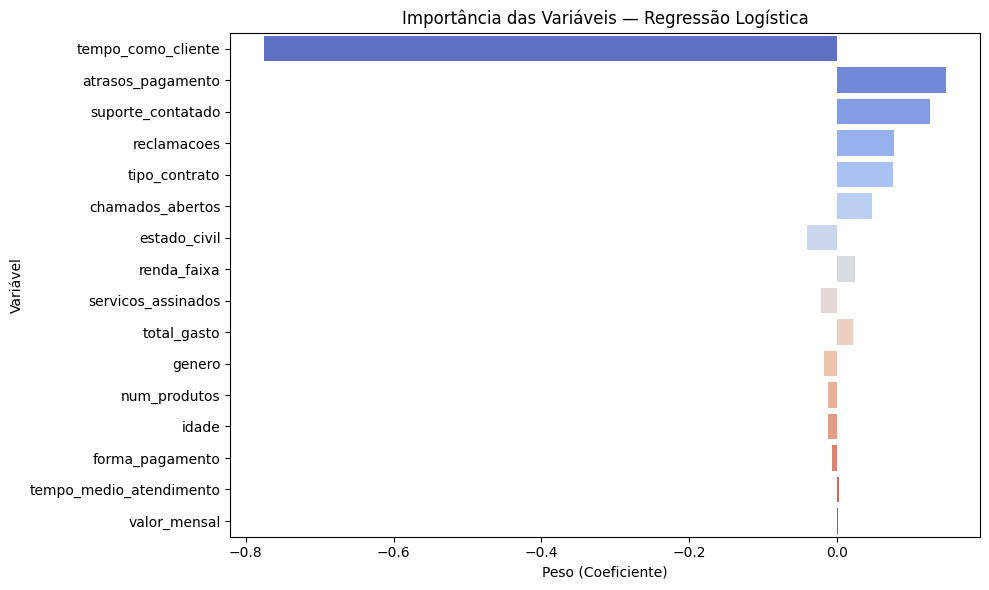

In [23]:
importance_log = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': log_model.coef_[0]
})

# Ordenar por importância absoluta
importance_log['Importancia_Absoluta'] = importance_log['Coeficiente'].abs()
importance_log.sort_values(by='Importancia_Absoluta', ascending=False, inplace=True)

# Visualizar
plt.figure(figsize=(10,6))
sns.barplot(x='Coeficiente', y='Feature', data=importance_log, palette='coolwarm')
plt.title('Importância das Variáveis — Regressão Logística')
plt.xlabel('Peso (Coeficiente)')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()


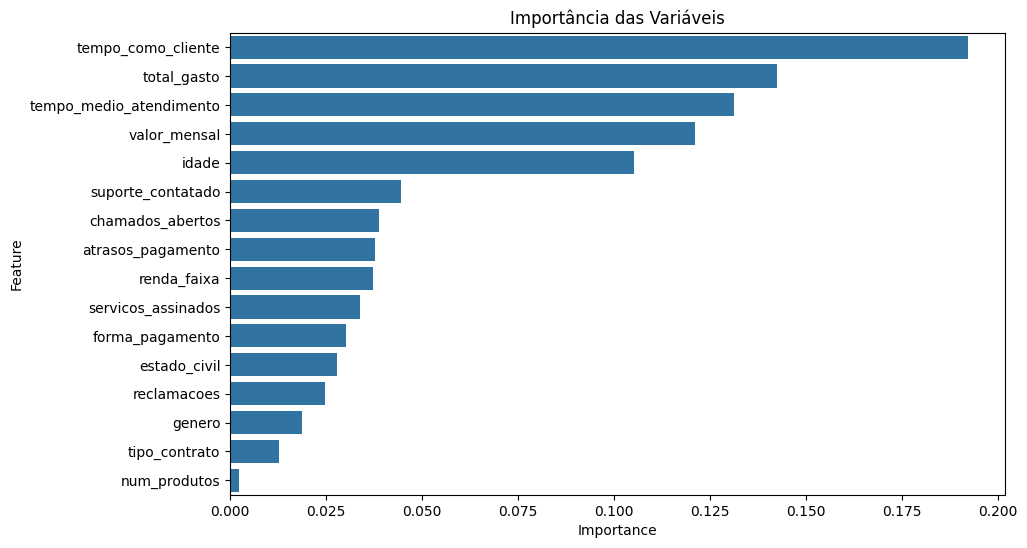

In [21]:
# Importância das Features da Random Forest
importances = rf_model.feature_importances_
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance.sort_values(by='Importance', ascending=False, inplace=True)

# Visualizar
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Importância das Variáveis')
plt.show()


<ipython-input-24-556f9fa50c74>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_log, palette='coolwarm', ax=axes[0])
<ipython-input-24-556f9fa50c74>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_rf, palette='viridis', ax=axes[1])


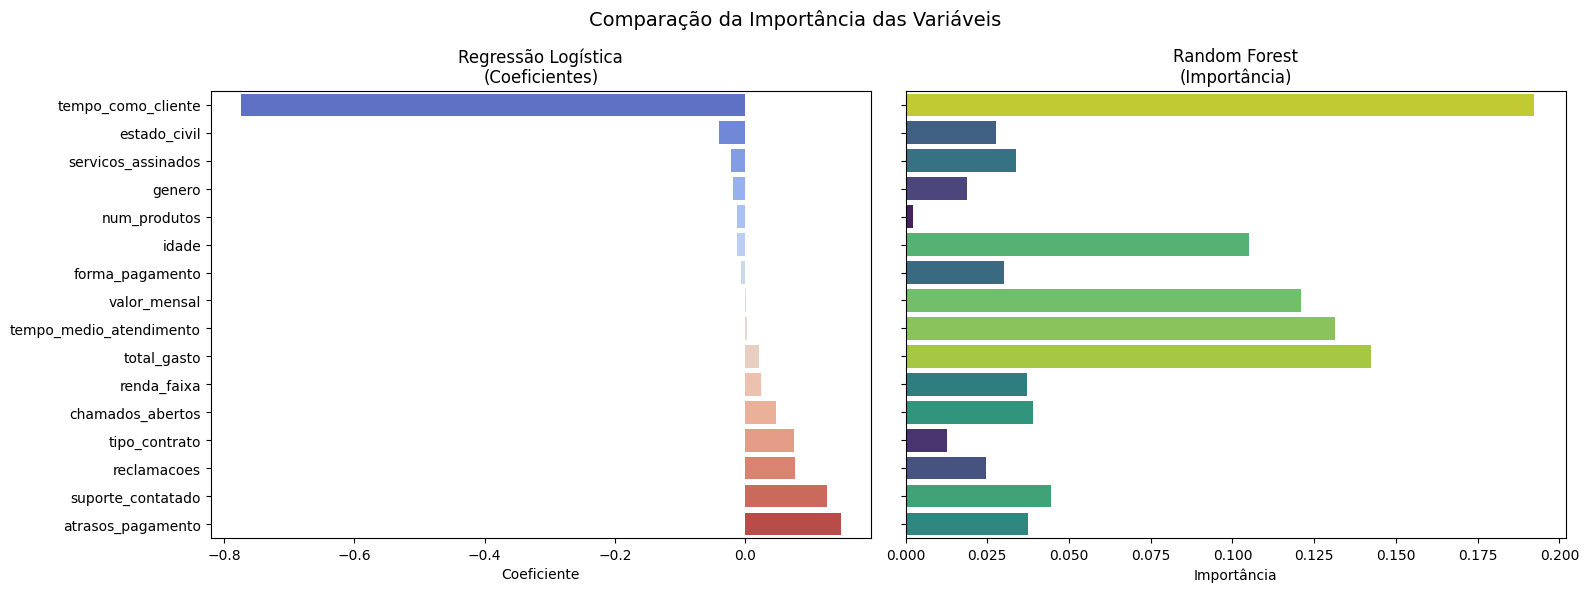

In [24]:
# Organizar importância da Regressão Logística
importance_log = pd.DataFrame({
    'Feature': X.columns,
    'Importance': log_model.coef_[0]
})
importance_log.sort_values(by='Importance', inplace=True)

# Organizar importância da Random Forest
importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})
importance_rf.sort_values(by='Importance', inplace=True)

# Gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Gráfico Regressão Logística
sns.barplot(x='Importance', y='Feature', data=importance_log, palette='coolwarm', ax=axes[0])
axes[0].set_title('Regressão Logística\n(Coeficientes)')
axes[0].set_xlabel('Coeficiente')
axes[0].set_ylabel('')

# Gráfico Random Forest
sns.barplot(x='Importance', y='Feature', data=importance_rf, palette='viridis', ax=axes[1])
axes[1].set_title('Random Forest\n(Importância)')
axes[1].set_xlabel('Importância')
axes[1].set_ylabel('')

plt.suptitle('Comparação da Importância das Variáveis', fontsize=14)
plt.tight_layout()
plt.show()


A partir da comparação entre a Regressão Logística e a Random Forest, observamos que a variável tempo_como_cliente aparece como a mais relevante nos dois modelos, indicando forte relação com o churn.

Além disso, variáveis como total_gasto, valor_mensal e num_produtos também tiveram destaque na Random Forest, sugerindo que o perfil de consumo do cliente tem grande impacto na decisão de cancelamento. Já na Regressão Logística, variáveis como atrasos_pagamento e suporte_contatado mostraram influência positiva no risco de churn, o que pode indicar insatisfação ou dificuldades com o serviço.

#### OBSERVAÇÃO:

Eu acabei excluindo a parte do código que fazia isso, mas eu também realizei o treinamento do modelo, sem a coluna tempo_como_cliente, e ambos os modelos tiveram uma redução da acurácia, que caiu para cerca de 60%.

Fazendo uma breve relação disso,a nível de mercado a Acurácia não é o fator mais analisado, provavelmente teriam outras métricas que fariam mais sentido analisar, removendo essa coluna, porém como a Acurácia é algo relevante para esse case, então eu a mantive no dataset.

---
Após esses resultados eu executei uma otimização de hiperparâmetros, usando o RandomizedSearchCV.

In [9]:
from sklearn.model_selection import RandomizedSearchCV

# Definindo o espaço de busca dos hiperparâmetros
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Instanciar o modelo base
rf_base = RandomForestClassifier(random_state=42)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=30,                # Número de combinações testadas
    cv=5,                     # Validação cruzada
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Treinar a busca
random_search.fit(X_train, y_train)

# Melhor modelo encontrado
best_rf_model = random_search.best_estimator_

# Prever no conjunto de validação
y_pred_best_rf = best_rf_model.predict(X_val)

# Avaliação
print("Random Forest Otimizado:")
print(classification_report(y_val, y_pred_best_rf))
print("Acurácia:", accuracy_score(y_val, y_pred_best_rf))

# Ver melhores hiperparâmetros encontrados
print("Melhores hiperparâmetros encontrados:")
print(random_search.best_params_)



Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
35 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
26 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", l

Random Forest Otimizado:
              precision    recall  f1-score   support

           0       0.75      0.88      0.81     13120
           1       0.64      0.41      0.50      6655

    accuracy                           0.72     19775
   macro avg       0.69      0.65      0.66     19775
weighted avg       0.71      0.72      0.71     19775

Acurácia: 0.724551201011378
Melhores hiperparâmetros encontrados:
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}


Após a otimização desse modelo, os melhores hiperparâetros encontrados foram:

`{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}`

E a acurácia obtida foi de 72%. Mas ainda sim, isso não foi suficiente...

## Parte 2 - Redes Neurais

Ainda não satisfeita com os resultados obtidos anteriormente, eu busquei executar duas redes neurais, como forma de verificar como o modelo responderia a elas.

A primeira rede implementada foi a Rede Neural Artificial (RNA) do tipo Perceptron Multicamadas (MLP - Multi-Layer Perceptron), implementada com a biblioteca Keras (TensorFlow), com a seguinte arquitetura:

| Camada             | Tipo        | Neurônios | Função de Ativação | Observações        |
|--------------------|-------------|-----------|---------------------|--------------------|
| Camada de Entrada  | Dense       | 64        | ReLU                | `input_dim = nº de features` |
| Camada Oculta 1    | Dropout     | -         | -                   | Dropout 30%        |
| Camada Oculta 2    | Dense       | 32        | ReLU                | -                  |
| Camada Oculta 3    | Dropout     | -         | -                   | Dropout 30%        |
| Camada de Saída    | Dense       | 1         | Sigmoid             | Saída binária (churn ou não) |

Enquanto isso, a segunda rede foi uma Rede Neural Profunda do tipo MLP (Perceptron Multicamadas), com regularização via Dropout e EarlyStopping para evitar overfitting. E teve a seguinte arquitetura:

| Camada             | Tipo        | Neurônios | Função de Ativação | Observações                 |
|--------------------|-------------|-----------|---------------------|-----------------------------|
| Camada de Entrada  | Dense       | 128       | ReLU                | `input_dim = nº de features` |
| Camada Oculta 1    | Dropout     | -         | -                   | Dropout 40% (regularização) |
| Camada Oculta 2    | Dense       | 64        | ReLU                | -                           |
| Camada Oculta 3    | Dropout     | -         | -                   | Dropout 30%                 |
| Camada Oculta 4    | Dense       | 32        | ReLU                | -                           |
| Camada Oculta 5    | Dropout     | -         | -                   | Dropout 20%                 |
| Camada de Saída    | Dense       | 1         | Sigmoid             | Saída binária (churn ou não) |



In [10]:
# Importar bibliotecas
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Criar o modelo
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))  # Saída binária (0 ou 1)

# Compilar o modelo
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Treinar o modelo
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

# Avaliar
loss, accuracy = model.evaluate(X_val, y_val)
print(f"Acurácia da rede neural: {accuracy:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
2472/2472 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6934 - loss: 0.6029 - val_accuracy: 0.7242 - val_loss: 0.5711
Epoch 2/50
2472/2472 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7186 - loss: 0.5770 - val_accuracy: 0.7246 - val_loss: 0.5703
Epoch 3/50
2472/2472 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7215 - loss: 0.5744 - val_accuracy: 0.7258 - val_loss: 0.5690
Epoch 4/50
2472/2472 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7217 - loss: 0.5738 - val_accuracy: 0.7252 - val_loss: 0.5694
Epoch 5/50
2472/2472 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7254 - loss: 0.5710 - val_accuracy: 0.7248 - val_loss: 0.5694
Epoch 6/50
2472/2472 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7253 - loss: 0.5717 - val_accuracy: 0.7251 - val_loss: 0.5681
Epoch 7/50
2472/2472 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7235 - loss: 0.5703 - val_accuracy: 0.7240 - val_loss: 0.5692
Epoch 8/50
2472/2472 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7246 - loss: 0.5704

In [11]:
# Imports necessários
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Definindo o modelo
model = Sequential()
model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.4))  # Regularização
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))  # Saída binária

# Compilando
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Treinando
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,    # batch_size menor para melhor aprendizado
    callbacks=[early_stop],
    verbose=1
)

# Avaliando
loss, accuracy = model.evaluate(X_val, y_val)
print(f"Acurácia da rede neural otimizada: {accuracy:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
4944/4944 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.6984 - loss: 0.5982 - val_accuracy: 0.7223 - val_loss: 0.5727
Epoch 2/100
4944/4944 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7209 - loss: 0.5750 - val_accuracy: 0.7241 - val_loss: 0.5738
Epoch 3/100
4944/4944 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.7230 - loss: 0.5723 - val_accuracy: 0.7206 - val_loss: 0.5743
Epoch 4/100
4944/4944 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7237 - loss: 0.5711 - val_accuracy: 0.7220 - val_loss: 0.5740
Epoch 5/100
4944/4944 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.7227 - loss: 0.5724 - val_accuracy: 0.7199 - val_loss: 0.5754
Epoch 6/100
4944/4944 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.7236 - loss: 0.5709 - val_accuracy: 0.7238 - val_loss: 0.5706
Epoch 7/100
4944/4944 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7259 - loss: 0.5704 - val_accuracy: 0.7242 - val_loss: 0.5725
Epoch 8/100
4944/4944 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.7221 -

Apesar dos esforços para tentar aumentar a acurácia ambas as Redes Neurais obtiveram desempenho semelhante ao apresentado pelo algoritmo de Regressão Logística.

Devido a compromissos que surgiram ao longo do caminho, eu confesso que não dediquei tanto tempo para a resolução do case. Dessa forma, não fiz de forma completa a exploração e o tratamento dos dados. Além disso, também confesso, que desempenhei mais tempo ao treinamento dos modelos do que às outras etapas (Talvez isso seja um enviesamento, dado que durante o estágio eu ouvi muito: "Joga no modelo e vê o que dá", isso porque, normalmente quando estamos com uma grande base de dados não é possível fazer uma análise minuciosa desses dados, logo modelos são treinados como forma de verificar como eles respondem aos dados disponíveis e a partir são geradas as análises, por conta disso, eu tentei agregar mais valor ao próprio treinamento do que a exploração dos dados em si).

Não sei se isso era o esperado, mas estou a diposição para caso queiram discutir sobre as decisões tomadas e receber feedbacks.

Agora, nos encaminho para a parte final do case, na qual irei gerar o csv de resultado.

In [28]:
def gerar_resultado_csv(caminho_csv_teste, modelo_treinado, scaler, label_encoders, nome_arquivo='resultado_seu_nome.csv'):
    # 1. Carrega os dados
    df_teste = pd.read_csv(caminho_csv_teste)
    ids = df_teste['id_cliente']  # salvar IDs para o CSV final

    # 2. Pré-processamento
    df_teste['num_produtos'] = df_teste['produtos_assinados'].apply(lambda x: len(eval(x)))

    # Codificação das variáveis categóricas com os MESMOS LabelEncoders do treino
    for col in label_encoders:
        df_teste[col] = label_encoders[col].transform(df_teste[col])

    # Remover colunas não utilizadas
    df_teste.drop(columns=['id_cliente', 'produtos_assinados'], inplace=True)

    # Normalizar com o MESMO scaler
    X_teste = scaler.transform(df_teste)

    # 3. Prever
    probs = modelo_treinado.predict(X_teste)
    preds = (probs > 0.5).astype(int).flatten()

    # 4. Criar DataFrame de resultado
    resultado = pd.DataFrame({'Id': ids, 'Target': preds})

    # 5. Exportar para CSV
    resultado.to_csv(nome_arquivo, index=False)
    print(f"Arquivo '{nome_arquivo}' gerado com sucesso!")

In [29]:
  gerar_resultado_csv(
    caminho_csv_teste='desafio.csv',
    modelo_treinado= log_model,
    scaler=scaler,
    label_encoders=label_encoders,
    nome_arquivo='resultado_giovanna_vieira.csv'
)

Arquivo 'resultado_giovanna_vieira.csv' gerado com sucesso!


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Bom, encerramos por aqui. Agradeço a toda a equipe do Inteli Academy pelo desafio, de fato foi muito divertido desenvolver esse case, interagir com os outros participantes do processo para dizer o quanto o Pedro nos sofrer e qual acurácia estava dando o nosso modelo. Logo, obrigada a todos pela oportunidade e espero vê-los em breve, mas como membra da Liga!!!